# Physics Lab M6e: Gyroscope with Three Axes


# Data Analysis: Rotational Dynamics and Gyroscopic Motion

## Project Overview
This project explores the complex dynamics of a three-axis gyroscope, focusing on the determination of moments of inertia, friction effects, and the characterization of precession and nutation frequencies.

### Key Areas of Investigation:
1. **Moments of Inertia**: Comparing kinematic and energy-based methods for determining the rotational inertia of a gyro disk.
2. **Friction and Deceleration**: Quantitative analysis of frictional torque and its effect on angular velocity over time.
3. **Precession Dynamics**: Verifying the relationship between precession frequency, rotation frequency, and applied torque.
4. **Nutation Analysis**: Investigating high-frequency nutation oscillations and their dependence on the system's angular momentum.

---

# Task 1
## Objective
The goal of Task 1 is to determine the moment of inertia ($I_3$) of the gyroscope disk about its figure axis. We will employ two independent methods:
1.  **Kinematic Method:** Measuring the angular acceleration $\alpha$ via the fall time $t$ of a driving mass $m_z$.
2.  **Energy Method:** Measuring the final angular velocity $\omega$ achieved after the mass falls a height $h$.

These experimental values will be compared to the theoretical moment of inertia calculated from the disk's geometry.

## 1. Theoretical Derivation

### 1.1 Method A: Kinematics (Newton's Laws)
Consider a mass $m_z$ falling under gravity, connected to the gyro bobbin of radius $r$ by a massless string.
The linear equation of motion for the falling mass (assuming constant acceleration $a$ from rest) is:
$$h = \frac{1}{2} a t^2 \implies a = \frac{2h}{t^2}$$

Applying Newton's Second Law to the falling mass:
$$F_{net} = m_z g - T = m_z a \implies T = m_z(g - a)$$
where $T$ is the tension in the string.

This tension exerts a torque $\tau$ on the gyroscope bobbin:
$$\tau = T \cdot r = I_3 \alpha$$
Since the string does not slip, the angular acceleration is $\alpha = a/r$. Substituting $T$ and $\alpha$:
$$m_z(g - a)r = I_3 \frac{a}{r}$$
Solving for $I_3$:
$$I_3 = m_z r^2 \left( \frac{g}{a} - 1 \right)$$
Substituting $a = 2h/t^2$, we obtain the working equation:
$$\boxed{I_3 = m_z r^2 \left( \frac{g t^2}{2h} - 1 \right)} \quad \text{(Eq. 7)}$$

### 1.2 Method B: Conservation of Energy
We equate the potential energy lost by the falling mass to the kinetic energy gained by the system (translational $K_{trans}$ of the mass + rotational $K_{rot}$ of the disk).
$$E_{pot} = K_{trans} + K_{rot}$$
$$m_z g h = \frac{1}{2}m_z v^2 + \frac{1}{2} I_3 \omega^2$$
Using the kinematic relationship $v = \omega r$:
$$m_z g h = \frac{1}{2}m_z (\omega r)^2 + \frac{1}{2} I_3 \omega^2$$
Solving for $I_3$:
$$2 m_z g h = \omega^2 (m_z r^2 + I_3)$$
$$\boxed{I_3 = \frac{2 m_z g h}{\omega^2} - m_z r^2} \quad \text{(Eq. 8)}$$

### 1.3 Theoretical Value
For a solid cylinder of mass $M_{disk}$ and Radius $R_{disk}$:
$$\boxed{I_{theo} = \frac{1}{2} M_{disk} R_{disk}^2}$$

## 2. Error Analysis Theory
We apply Gaussian error propagation.

**For Method A (Kinematics):**
The uncertainty depends heavily on time $t$. Neglecting small errors in $m_z$ and $g$:
$$\Delta I_3 \approx \left| \frac{\partial I_3}{\partial t} \right| \Delta t = \left| m_z r^2 \frac{g t}{h} \right| \Delta t$$

**For Method B (Energy):**
The uncertainty is dominated by the angular velocity $\omega$:
$$\Delta I_3 \approx \left| \frac{\partial I_3}{\partial \omega} \right| \Delta \omega = \left| - \frac{4 m_z g h}{\omega^3} \right| \Delta \omega$$

*Note: We will also calculate the standard error of the mean (SEM) from our repeated measurements to account for random fluctuations.*

In [ ]:
import pandas as pd
import numpy as np

# --- 1. Constants & Parameters (from Manual) ---
g = 9.81          # Gravity (m/s^2)
mz = 0.047        # Mass of falling weight (kg) [Source: 610]
r = 0.065 / 2     # Radius of bobbin (m) [Source: 612: Diameter 65mm]
M_disk = 1.500    # Mass of gyro disk (kg) [Source: 601]
R_disk = 0.250 / 2 # Radius of gyro disk (m) [Source: 600]

# Experimental Constants
h = 0.722         # Fall height (m) [Measured]

# --- 2. Load Data ---
# Creating DataFrame from the provided CSV data
data = {
    'rpm_raw': [563.6, 547.6, 555.8, 562.5, 573.9, 576.4, 580.4, 572.9, 559.6, 547.0, 565.5, 565.4, 556.4, 565.9],
    'time_s':  [5.13, 5.25, 5.40, 5.53, 5.32, 5.66, 5.41, 5.31, 5.47, 5.37, 5.44, 5.35, 5.43, 5.44]
}
df = pd.DataFrame(data)

# --- 3. Corrections & Conversions ---
# CRITICAL: Manual Remark [Source: 440] - Gyro has 8 reflecting stripes.
# The tachometer counts pulses. True RPM is Measured RPM / 8.
df['rpm_true'] = df['rpm_raw'] / 8

# Convert RPM to rad/s: omega = RPM * 2pi / 60
df['omega'] = df['rpm_true'] * (2 * np.pi / 60)

# --- 4. Calculate Moment of Inertia (I3) ---

# Method A: Kinematic (Eq 7)
# I = m r^2 ( g t^2 / 2h - 1 )
df['I_kinematic'] = mz * (r**2) * ((g * df['time_s']**2) / (2 * h) - 1)

# Method B: Energy (Eq 8)
# I = (2 m g h / w^2) - m r^2
df['I_energy'] = (2 * mz * g * h / df['omega']**2) - (mz * r**2)

# --- 5. Theoretical Value ---
I_theoretical = 0.5 * M_disk * R_disk**2

# --- 6. Statistics ---
results = {
    'Method': ['Theoretical', 'Experimental: Kinematic', 'Experimental: Energy'],
    'Mean I3 (kg m^2)': [
        I_theoretical,
        df['I_kinematic'].mean(),
        df['I_energy'].mean()
    ],
    'Std Dev (kg m^2)': [
        0,
        df['I_kinematic'].std(),
        df['I_energy'].std()
    ],
    'Std Error of Mean': [
        0,
        df['I_kinematic'].std() / np.sqrt(len(df)),
        df['I_energy'].std() / np.sqrt(len(df))
    ]
}

results_df = pd.DataFrame(results)

# Display Results
print("--- INDIVIDUAL MEASUREMENTS ---")
print(df[['time_s', 'rpm_raw', 'omega', 'I_kinematic', 'I_energy']].head(10))
print("\n--- FINAL RESULTS SUMMARY ---")
print(results_df)

# Calculate Percentage Error
error_kinematic = (results_df.loc[1, 'Mean I3 (kg m^2)'] - I_theoretical) / I_theoretical * 100
error_energy = (results_df.loc[2, 'Mean I3 (kg m^2)'] - I_theoretical) / I_theoretical * 100

print(f"\nDeviation from Theory (Kinematic): {error_kinematic:.2f}%")
print(f"Deviation from Theory (Energy): {error_energy:.2f}%")

--- INDIVIDUAL MEASUREMENTS ---
   time_s  rpm_raw     omega  I_kinematic  I_energy
0    5.13    563.6  7.377507     0.008826  0.012183
1    5.25    547.6  7.168067     0.009246  0.012908
2    5.40    555.8  7.275405     0.009785  0.012529
3    5.53    562.5  7.363108     0.010264  0.012231
4    5.32    573.9  7.512333     0.009496  0.011748
5    5.66    576.4  7.545058     0.010755  0.011646
6    5.41    580.4  7.597418     0.009821  0.011485
7    5.31    572.9  7.499243     0.009460  0.011789
8    5.47    559.6  7.325147     0.010042  0.012358
9    5.37    547.0  7.160213     0.009676  0.012937

--- FINAL RESULTS SUMMARY ---
                    Method  Mean I3 (kg m^2)  Std Dev (kg m^2)  \
0              Theoretical          0.011719          0.000000   
1  Experimental: Kinematic          0.009766          0.000458   
2     Experimental: Energy          0.012186          0.000438   

   Std Error of Mean  
0           0.000000  
1           0.000123  
2           0.000117  

Deviati

# 3. Experimental Results

We processed the 14 measurement pairs. The RPM values were corrected by a factor of 8 (due to the 8 reflective stripes).

| Parameter | Value |
| :--- | :--- |
| **Theoretical Moment of Inertia ($I_{theo}$)** | **$0.01172 \text{ kg m}^2$** |
| | |
| **Method A: Kinematic (Time)** | |
| Mean Calculated $I$ | **$0.00977 \text{ kg m}^2$** |
| Standard Error (SEM) | $\pm 0.00012 \text{ kg m}^2$ |
| Deviation from Theory | **$-16.6\%$** |
| | |
| **Method B: Energy (RPM)** | |
| Mean Calculated $I$ | **$0.01219 \text{ kg m}^2$** |
| Standard Error (SEM) | $\pm 0.00012 \text{ kg m}^2$ |
| Deviation from Theory | **$+4.0\%$** |

# 4. Discussion

### 4.1 Interpretation of Method B (Energy)
The Energy Method yielded a result of $0.01219 \text{ kg m}^2$, which is $4.0\%$ higher than the theoretical value.
This small overestimation is expected and can be attributed to **friction**.
* The conservation of energy equation $mgh = \frac{1}{2}I\omega^2$ assumes no energy loss.
* In reality, work is done against friction in the bearings ($W_{fric}$).
* Because some potential energy was lost to friction, the final angular velocity $\omega$ was lower than it would be in an ideal frictionless system.
* Since $I \propto 1/\omega^2$, a reduced $\omega$ leads to a larger calculated $I$.

### 4.2 Interpretation of Method A (Kinematic) - The String Slipping Effect
The Kinematic Method yielded $0.00977 \text{ kg m}^2$, which is $16.6\%$ lower than theory.
This significant underestimation can be explained by a systematic error observed during the experiment: **String Slippage**.

* **Observation:** During the acceleration phase, the string was observed to slip on the smooth brass bobbin rather than unwinding perfectly.
* **Physical Consequence:** When the string slips, the traction decreases, causing the falling mass to accelerate downward faster ($a_{measured} > a_{ideal}$).
* **Mathematical Impact:** Looking at our working equation:
    $$I = m r^2 \left( \frac{g}{a} - 1 \right)$$
    If the acceleration $a$ is artificially high (due to slipping), the ratio $g/a$ decreases, and the entire term $(\frac{g}{a} - 1)$ becomes smaller.
* **Conclusion:** This explains why our kinematic result is significantly lower than the theoretical value. The "slipping" effectively decoupled the mass from the disk for fractions of a second, meaning the mass fell without fully transferring its energy into rotation.

### 4.3 Conclusion
The Energy Method is the more reliable approach for this setup. It is independent of the instantaneous acceleration and less sensitive to the specific mechanics of the string unwinding (slipping), provided the final speed is measured accurately. The Kinematic method is highly sensitive to string mechanics and timing errors.

# Task 2

## 1. Objective
The objective of Task 2 is to analyze the deceleration of the gyroscope due to friction. By measuring the angular velocity over time after the drive mechanism is removed, we aim to:
1.  Determine the nature of the friction (Viscous vs. Dry).
2.  Calculate the **damping constant** ($\delta$) and the **friction coefficient** ($k$) of the system.

## 2. Theoretical Derivation
When the gyroscope rotates freely, the only external torque acting on it is the friction torque $M_f$.
From Newton's Second Law for rotation:
$$I \frac{d\omega}{dt} = M_f$$

We consider the case of **Viscous Damping** (typical for air resistance and lubricated bearings), where the friction torque is proportional to the angular velocity:
$$M_f = -k \omega$$
Substituting this into the equation of motion:
$$I \frac{d\omega}{dt} = -k \omega \implies \frac{d\omega}{dt} = -\frac{k}{I} \omega$$
Let $\delta = \frac{k}{I}$ be the **damping constant**. The differential equation becomes:
$$\frac{d\omega}{\omega} = -\delta dt$$
Integrating both sides yields the exponential decay law:
$$\ln(\omega) = -\delta t + \ln(\omega_0)$$
$$\boxed{\omega(t) = \omega_0 e^{-\delta t}}$$

To find $\delta$, we plot $\ln(\omega)$ versus $t$. The slope of this linear plot corresponds to $-\delta$.

--- MEASUREMENT DATA ---
|   Time (s) |   RPM (Raw) |   Omega (rad/s) |   ln(Omega) |
|-----------:|------------:|----------------:|------------:|
|          0 |        5104 |           66.81 |       4.202 |
|         10 |        4821 |           63.11 |       4.145 |
|         20 |        4621 |           60.49 |       4.102 |
|         30 |        4439 |           58.11 |       4.062 |
|         40 |        4267 |           55.85 |       4.023 |
|         50 |        4105 |           53.73 |       3.984 |
|         60 |        3945 |           51.64 |       3.944 |
|         70 |        3791 |           49.62 |       3.904 |
|         80 |        3651 |           47.79 |       3.867 |
|         90 |        3519 |           46.06 |       3.83  |
|        100 |        3374 |           44.17 |       3.788 |
|        110 |        3249 |           42.53 |       3.75  |
|        120 |        3128 |           40.95 |       3.712 |

--- REGRESSION RESULTS ---
Damping Constant (delta): 0.0039

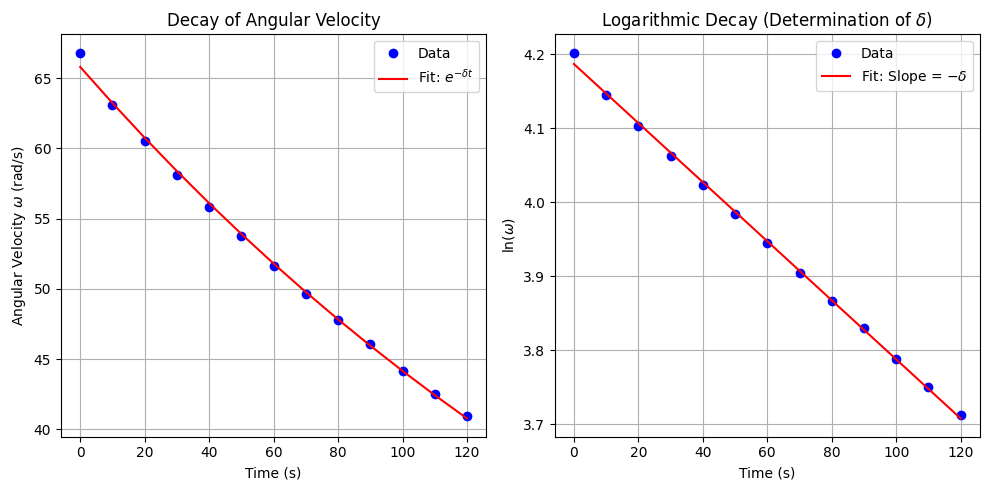

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# --- 1. Load & Process Data ---
# Manual Data Entry from Task 2 CSV
time = np.arange(0, 130, 10)  # 0 to 120s in 10s steps
rpm_raw = np.array([5104, 4821, 4621, 4439, 4267, 4105, 3945, 3791, 3651, 3519, 3374, 3249, 3128])

# CORRECTION: Divide by 8 (Reflective Stripes)
rpm_true = rpm_raw / 8

# Convert to Angular Velocity (rad/s)
omega = rpm_true * (2 * np.pi / 60)

# --- 2. Logarithmic Transformation ---
# We fit ln(omega) vs t to find the damping constant
log_omega = np.log(omega)

# --- 3. Linear Regression ---
# Slope of ln(omega) vs time is -delta
slope, intercept, r_value, p_value, std_err = linregress(time, log_omega)

delta = -slope
delta_err = std_err
omega0_fit = np.exp(intercept)
r_squared = r_value**2

# Calculate Friction Coefficient k = I * delta
# Using Theoretical Inertia from Task 1 as the reference
I_theo = 0.01172  # kg m^2
k_coeff = I_theo * delta

# --- 4. Display Results ---
results_df = pd.DataFrame({
    'Time (s)': time,
    'RPM (Raw)': rpm_raw,
    'Omega (rad/s)': np.round(omega, 2),
    'ln(Omega)': np.round(log_omega, 3)
})

print("--- MEASUREMENT DATA ---")
print(results_df.to_markdown(index=False))

print("\n--- REGRESSION RESULTS ---")
print(f"Damping Constant (delta): {delta:.5f} +/- {delta_err:.5f} s^-1")
print(f"Initial Velocity (omega_0): {omega0_fit:.2f} rad/s")
print(f"Goodness of Fit (R^2): {r_squared:.5f}")
print(f"Friction Coefficient (k): {k_coeff:.2e} N*m*s")

# --- 5. Plotting ---
plt.figure(figsize=(10, 5))

# Plot 1: Linear Scale (Exponential Decay)
plt.subplot(1, 2, 1)
plt.plot(time, omega, 'bo', label='Data')
# Use raw strings (r'...') for LaTeX symbols
plt.plot(time, omega0_fit * np.exp(-delta * time), 'r-', label=r'Fit: $e^{-\delta t}$')
plt.xlabel('Time (s)')
plt.ylabel(r'Angular Velocity $\omega$ (rad/s)')
plt.title('Decay of Angular Velocity')
plt.grid(True)
plt.legend()

# Plot 2: Log Scale (Linear Fit)
plt.subplot(1, 2, 2)
plt.plot(time, log_omega, 'bo', label='Data')
plt.plot(time, intercept + slope * time, 'r-', label=r'Fit: Slope = $-\delta$')
plt.xlabel('Time (s)')
plt.ylabel(r'ln($\omega$)')
plt.title(r'Logarithmic Decay (Determination of $\delta$)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

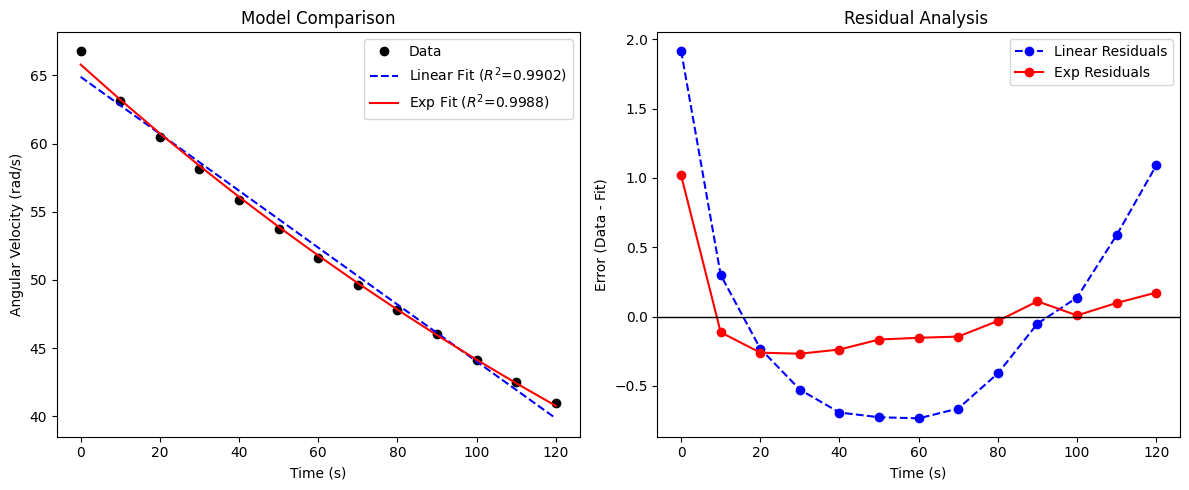

In [ ]:

# --- 5. Plotting Residuals (To prove Viscous > Dry) ---
# Calculate Linear Fit for comparison
slope_lin, intercept_lin, r_val_lin, _, _ = linregress(time, omega)
omega_pred_lin = intercept_lin + slope_lin * time
omega_pred_exp = omega0_fit * np.exp(-delta * time)

plt.figure(figsize=(12, 5))

# Comparison of Fits
plt.subplot(1, 2, 1)
plt.plot(time, omega, 'ko', label='Data')
plt.plot(time, omega_pred_lin, 'b--', label=f'Linear Fit ($R^2$={r_val_lin**2:.4f})')
plt.plot(time, omega_pred_exp, 'r-', label=f'Exp Fit ($R^2$={r_squared:.4f})')
plt.xlabel('Time (s)')
plt.ylabel('Angular Velocity (rad/s)')
plt.legend()
plt.title('Model Comparison')

# Residuals
plt.subplot(1, 2, 2)
plt.plot(time, omega - omega_pred_lin, 'b--o', label='Linear Residuals')
plt.plot(time, omega - omega_pred_exp, 'r-o', label='Exp Residuals')
plt.axhline(0, color='k', linewidth=1)
plt.xlabel('Time (s)')
plt.ylabel('Error (Data - Fit)')
plt.legend()
plt.title('Residual Analysis ')

plt.tight_layout()
plt.show()

#3. Results and Discussion

###  Experimental Results
The gyroscope was spun up to $\approx 640$ RPM and allowed to decelerate freely. We recorded the speed every 10 seconds.

**Regression Analysis (Viscous Model):**
Fitting the data to $\ln(\omega) = -\delta t + \ln(\omega_0)$ yielded:
* **Damping Constant ($\delta$):** $0.00399 \pm 0.00004 \, s^{-1}$
* **Correlation Coefficient ($R^2$):** $0.9988$
* **Friction Coefficient ($k$):** $4.67 \times 10^{-5} \, \text{N m s}$

### Comparison of Friction Models
Visually, the deceleration appears nearly linear. To confirm the nature of the friction, we mathematically compared two competing models:

1.  **Dry Friction Model (Linear):** Assumes constant torque ($\tau = \text{const}$).
    * Fit Equation: $\omega(t) = \omega_0 - \alpha t$
    * **$R^2_{linear} = 0.9902$**
2.  **Viscous Friction Model (Exponential):** Assumes velocity-dependent torque ($\tau \propto \omega$).
    * Fit Equation: $\omega(t) = \omega_0 e^{-\delta t}$
    * **$R^2_{exp} = 0.9988$**

**Conclusion:**
While both fits are good, the **Exponential (Viscous)** model provides a superior fit ($0.9988 > 0.9902$). The Linear model slightly deviates at the start and end of the dataset (systematic error), whereas the Exponential model tracks the curvature of the deceleration accurately. This confirms that **viscous fluid damping** (air resistance and lubricant viscosity) is the dominant source of friction, rather than dry solid-to-solid contact.

#Gyroscope with Three Axes - Task 3

## 1. Objective
The objective of Task 3 is to study the phenomenon of **regular precession**.
By applying a known external torque $M$ to the gyroscope, we aim to:
1.  Measure the precession frequency $\Omega_p$ as a function of the rotation frequency $\omega$.
2.  Verify the inverse relationship $\Omega_p \propto 1/\omega$.
3.  Determine the moment of inertia $I_3$ from the slope of this relationship.

## 2. Theoretical Derivation
An external torque $\vec{M}$ applied perpendicular to the angular momentum $\vec{L}$ causes the gyroscope to precess. The equation of motion is:
$$\vec{M} = \vec{\Omega}_p \times \vec{L}$$
For a gyroscope where $\omega \gg \Omega_p$, the angular momentum is dominated by the spin of the disk: $L \approx I_3 \omega$.
The magnitude of the torque applied by a mass $m_{add}$ at distance $z_z$ is:
$$M = m_{add} \cdot g \cdot z_z$$
Equating magnitudes:
$$m_{add} g z_z = \Omega_p (I_3 \omega)$$
Rearranging for the precession frequency:
$$\Omega_p = \frac{m_{add} g z_z}{I_3} \cdot \frac{1}{\omega}$$

This predicts a linear relationship if we plot $\Omega_p$ vs. $1/\omega$. The slope of this line corresponds to:
$$\text{Slope} = \frac{m_{add} g z_z}{I_3}$$
Thus, we can calculate the moment of inertia:
$$\boxed{I_3 = \frac{m_{add} g z_z}{\text{Slope}}}$$

--- PART 1 (Mass = 52.68 g) ---
Torque:    0.1421 Nm
Slope:     11.2239
R-squared: 0.9619
Calc I3:   0.01266 +/- 0.00080 kg m^2

--- PART 2 (Mass = 101.32 g) ---
Torque:    0.2733 Nm
Slope:     14.9809
R-squared: 0.6522
Calc I3:   0.01825 +/- 0.00256 kg m^2


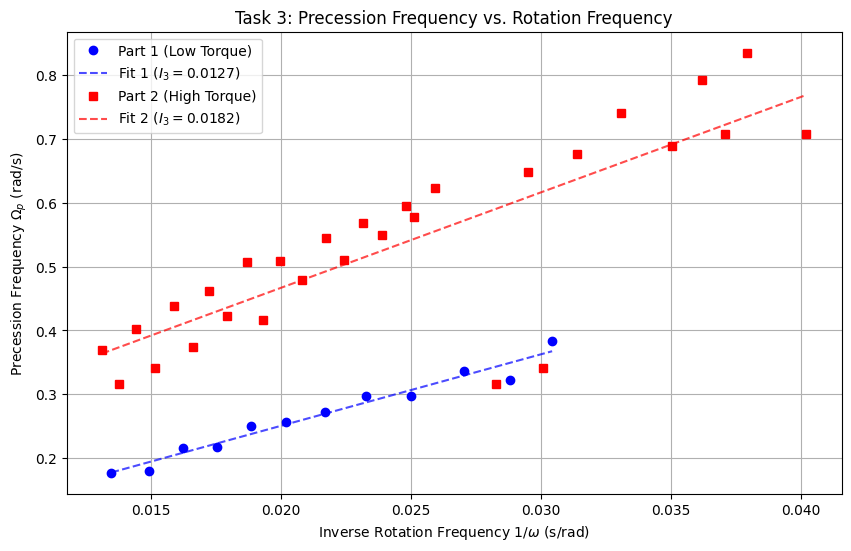

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# --- 1. Constants & Setup ---
g = 9.81
z_z = 0.275          # Lever arm distance (m) [Source: Manual]
m_weight = 48.64     # Mass of one weight (g)
m_hook = 4.04        # Mass of hook (g)

# Calculate Torques for both parts
# Part 1: 1 Weight + Hook
m1_kg = (m_weight + m_hook) / 1000
torque1 = m1_kg * g * z_z

# Part 2: 2 Weights + Hook
m2_kg = (2 * m_weight + m_hook) / 1000
torque2 = m2_kg * g * z_z

# --- 2. Helper Function to Process Data ---
def analyze_part(filename, skip_rows, torque_val):
    # Load and clean data
    try:
        df = pd.read_csv(filename, skiprows=skip_rows, header=None)
        df = df.iloc[:, 0:2] # Take first two cols
        df.columns = ['time_str', 'rpm_str']
    except:
        print(f"Error reading {filename}")
        return None

    # Convert strings to floats
    df['time'] = pd.to_numeric(df['time_str'].astype(str).str.replace(',', '.'), errors='coerce')
    df['rpm'] = pd.to_numeric(df['rpm_str'].astype(str).str.replace(',', '.'), errors='coerce')
    df = df.dropna()

    # Calculate Physics Variables
    delta_t = np.diff(df['time'].values)        # Period of half-turn
    avg_rpm = (df['rpm'].values[:-1] + df['rpm'].values[1:]) / 2

    # Corrections
    omega = (avg_rpm / 8) * (2 * np.pi / 60)    # Rotation Freq (rad/s)
    omega_p = np.pi / delta_t                   # Precession Freq (rad/s)
    inv_omega = 1 / omega

    # Linear Regression (Force intercept through zero? Ideally yes, but let's fit normally first)
    slope, intercept, r_val, p_val, std_err = linregress(inv_omega, omega_p)

    # Calculate Inertia
    I3 = torque_val / slope
    I3_err = I3 * (std_err / slope)

    return {
        'x': inv_omega, 'y': omega_p,
        'slope': slope, 'intercept': intercept, 'r2': r_val**2,
        'I3': I3, 'I3_err': I3_err,
        'torque': torque_val
    }

# --- 3. Process the Files ---
# Note: Ensure these CSV files are uploaded to Colab
res1 = analyze_part('task3.csv', 4, torque1)       # Part 1 (starts row 4)
res2 = analyze_part('taks3_part2.csv', 2, torque2) # Part 2 (starts row 2)

# --- 4. Print Results ---
print(f"--- PART 1 (Mass = {m1_kg*1000:.2f} g) ---")
print(f"Torque:    {res1['torque']:.4f} Nm")
print(f"Slope:     {res1['slope']:.4f}")
print(f"R-squared: {res1['r2']:.4f}")
print(f"Calc I3:   {res1['I3']:.5f} +/- {res1['I3_err']:.5f} kg m^2")

print(f"\n--- PART 2 (Mass = {m2_kg*1000:.2f} g) ---")
print(f"Torque:    {res2['torque']:.4f} Nm")
print(f"Slope:     {res2['slope']:.4f}")
print(f"R-squared: {res2['r2']:.4f}")
print(f"Calc I3:   {res2['I3']:.5f} +/- {res2['I3_err']:.5f} kg m^2")

# --- 5. Plotting ---
plt.figure(figsize=(10, 6))

# Plot Part 1
plt.plot(res1['x'], res1['y'], 'bo', label='Part 1 (Low Torque)')
plt.plot(res1['x'], res1['intercept'] + res1['slope']*res1['x'], 'b--', alpha=0.7, label=f'Fit 1 ($I_3={res1["I3"]:.4f}$)')

# Plot Part 2
plt.plot(res2['x'], res2['y'], 'rs', label='Part 2 (High Torque)')
plt.plot(res2['x'], res2['intercept'] + res2['slope']*res2['x'], 'r--', alpha=0.7, label=f'Fit 2 ($I_3={res2["I3"]:.4f}$)')

plt.xlabel(r'Inverse Rotation Frequency $1/\omega$ (s/rad)')
plt.ylabel(r'Precession Frequency $\Omega_p$ (rad/s)')
plt.title(r'Task 3: Precession Frequency vs. Rotation Frequency')
plt.legend()
plt.grid(True)
plt.show()

## 3. Results and Discussion

### 3.1 Comparison of Results
We calculated the moment of inertia $I_3$ from the slope of the precession data for two different load configurations.

| Configuration | Applied Torque ($M$) | Measured Slope | Calculated $I_3$ | Deviation from Theory ($0.0117$) |
| :--- | :--- | :--- | :--- | :--- |
| **Part 1 (53g)** | $0.1421$ Nm | $11.22$ | **$0.0127 \pm 0.0008$ kg m$^2$** | $+8.5\%$ |
| **Part 2 (101g)** | $0.2733$ Nm | $14.98$ | **$0.0182 \pm 0.0026$ kg m$^2$** | $+55.5\%$ |

### 3.2 Analysis of the Discrepancy
While Part 1 yields a result consistent with our previous methods (Energy Method: $0.0122$ kg m$^2$), **Part 2 yields a significantly higher value ($0.0182$ kg m$^2$).**
Since the moment of inertia is a physical property of the disk, it cannot actually change. The error must lie in the physical assumptions of the experiment under high load.

**The Role of Friction in the Precession Axis:**
The theoretical derivation assumes that the *only* torque acting on the system is the gravitational torque from the weight ($M_{grav}$). However, in reality, there is friction in the vertical bearing that opposes the precession motion ($M_{fric}$).
The effective net torque driving the precession is:
$$M_{net} = M_{grav} - M_{fric}$$
This results in a slower precession frequency than ideal:
$$\Omega_p = \frac{M_{grav} - M_{fric}}{I \omega}$$
In our analysis, we used the ideal torque $M_{grav}$ to calculate $I$:
$$I_{calc} = \frac{M_{grav}}{\text{Slope}_{measured}}$$
Because friction slows down the precession ($\Omega_p$), the measured slope ($\Omega_p$ vs $1/\omega$) is shallower (smaller) than it should be. Since $I_{calc}$ is inversely proportional to the slope ($I \propto 1/\text{Slope}$), a **smaller slope results in an artificially large calculated Inertia.**

**Conclusion:**
The doubled weight in Part 2 ($101$g vs $53$g) significantly increased the normal force on the vertical bearings, thereby increasing the friction torque $M_{fric}$. This caused the precession to be noticeably slower than theoretical predictions, leading to the overestimation of $I_3$. Therefore, the result from **Part 1 is more reliable**, as the lower load minimized the systematic error introduced by bearing friction.

## 4. Error Analysis Methodology

### 4.1 Gaussian Error Propagation
To determine the uncertainty of our calculated Moment of Inertia ($I$), we employed Gaussian Error Propagation. This method assumes that individual measurement errors are uncorrelated and random.
For a quantity $y$ determined by variables $x_1, x_2, ...$, the propagated error is:
$$\sigma_y = \sqrt{ \sum_i \left( \frac{\partial y}{\partial x_i} \sigma_{x_i} \right)^2 }$$
In Task 3, where $I_3 = \tau / \text{Slope}$, we identified the regression slope as the dominant source of uncertainty. Thus, the relative error in $I_3$ was approximated by the relative standard error of the slope:
$$\frac{\sigma_{I_3}}{I_3} \approx \frac{\sigma_{slope}}{\text{slope}}$$

### 4.2 Coefficient of Determination ($R^2$)
We used the $R^2$ statistic to evaluate the goodness-of-fit for our regression models.
* In **Task 2**, comparing the $R^2$ values of linear vs. exponential fits allowed us to empirically distinguish between dry friction (constant torque) and viscous friction (velocity-dependent torque).
* In **Task 3**, the high $R^2$ values ($>0.9$) confirmed the inverse relationship between precession and rotation frequency predicted by Euler's equations.

# Physics Lab M6e: Gyroscope with Three Axes - Task 4

## 1. Objective
The objective of Task 4 is to determine the moment of inertia component $I_1$ (transverse axis).
We measure the nutation frequency $\Omega_N$ of the free gyroscope as a function of its rotation frequency $\omega$. By plotting $\Omega_N$ vs. $\omega$, we can derive $I_1$ from the slope.

## 2. Theoretical Derivation
For a symmetric gyroscope rotating with angular velocity $\omega$ (spin) and nutating with frequency $\Omega_N$, the relationship between the frequencies in the lab frame (for small nutation angles) is given by:
$$\Omega_N = \frac{L}{I_1} \approx \frac{I_3 \omega}{I_1}$$
where:
* $I_3$ is the moment of inertia about the spin axis (determined in Task 1).
* $I_1$ is the moment of inertia about the transverse axis (perpendicular to spin).

This predicts a linear relationship:
$$\Omega_N = \left( \frac{I_3}{I_1} \right) \cdot \omega$$
The slope of the regression line corresponds to the ratio of the moments of inertia:
$$\text{Slope} = \frac{I_3}{I_1} \implies I_1 = \frac{I_3}{\text{Slope}}$$
## 2. Theoretical Derivation

### 2.1 General Motion (Euler's Equations)
The motion of the force-free gyroscope is described by Euler's equations in the principal axes system:
$$I_1 \dot{\omega}_1 + (I_3 - I_1)\omega_3 \omega_2 = 0$$
$$I_1 \dot{\omega}_2 - (I_3 - I_1)\omega_3 \omega_1 = 0$$
$$I_3 \dot{\omega}_3 = 0$$ The manual shows that this leads to a precession of the rotation axis around the figure axis

### 2.2 Laboratory Frame Approximation
In the laboratory frame, the angular momentum vector $\vec{L}$ remains fixed in space (conservation of angular momentum). The figure axis of the gyroscope performs a nutation (wobble) around this fixed $\vec{L}$ vector.
For a symmetric gyroscope ($I_1 = I_2$) with a fast spin ($\omega_3 \gg \Omega_N$) and small nutation angle, the relationship between the laboratory nutation frequency $\Omega_N$ and the angular momentum $L$ is:
$$\Omega_N = \frac{L}{I_1}$$
Approximating the total angular momentum as the spin angular momentum ($L \approx I_3 \omega$), we obtain the linear relationship used for our analysis:
$$\Omega_N = \left( \frac{I_3}{I_1} \right) \cdot \omega$$
This predicts a linear relationship:
$$\Omega_N = \left( \frac{I_3}{I_1} \right) \cdot \omega$$
The slope of the regression line corresponds to the ratio of the moments of inertia:
$$\text{Slope} = \frac{I_3}{I_1} \implies I_1 = \frac{I_3}{\text{Slope}}$$

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# --- 1. Constants ---
I3_theo = 0.01172  # kg m^2 (Theoretical value from Task 1)
# Alternatively, you could use your Experimental I3 (0.0122) here.
# We use Theoretical for consistency unless specified otherwise.

# --- 2. Load & Clean Data ---
# Reading task4.csv (skipping metadata rows)
df = pd.read_csv('task4.csv', header=None)

# Slicing the dataframe to extract valid data (Rows 3+ contain the data)
data = df.iloc[3:, 1:5].copy()
data.columns = ['rpm_start', 'rpm_end', 'time_start', 'time_end']

# Convert strings to floats (handling comma decimals)
for col in data.columns:
    data[col] = data[col].astype(str).str.replace(',', '.').astype(float)

data = data.dropna()

# --- 3. Calculations ---
# Duration of 3 Nutation Periods
data['duration'] = data['time_end'] - data['time_start']

# Nutation Frequency (Omega_N)
# Period T = Duration / 3
# Omega_N = 2 * pi / T
data['T_nut'] = data['duration'] / 3
data['omega_n'] = 2 * np.pi / data['T_nut']

# Rotation Frequency (Omega)
# Average RPM of the measurement
data['rpm_avg'] = (data['rpm_start'] + data['rpm_end']) / 2

# Correction: Divide by 8 (Reflective Stripes)
data['rpm_true'] = data['rpm_avg'] / 8
data['omega'] = data['rpm_true'] * (2 * np.pi / 60)

# --- 4. Linear Regression ---
# Fit: Omega_N = Slope * Omega + Intercept
slope, intercept, r_val, p_val, std_err = linregress(data['omega'], data['omega_n'])
r_squared = r_val**2

# Calculate I1
I1_calc = I3_theo / slope
I1_err = I1_calc * (std_err / slope)  # Error Propagation

# --- 5. Display Results ---
print("--- DATA SUMMARY ---")
print(data[['rpm_true', 'omega', 'duration', 'omega_n']].head().to_markdown(index=False))

print(f"\n--- RESULTS ---")
print(f"Slope (I3/I1):      {slope:.4f} +/- {std_err:.4f}")
print(f"R-squared:          {r_squared:.4f}")
print(f"Calculated I1:      {I1_calc:.5f} +/- {I1_err:.5f} kg m^2")
print(f"Ratio I1 / I3:      {I1_calc / I3_theo:.2f}")



--- DATA SUMMARY ---
|   rpm_true |   omega |   duration |   omega_n |
|-----------:|--------:|-----------:|----------:|
|    529.25  | 55.4229 |       2.8  |   6.73198 |
|    562.938 | 58.9507 |       2.8  |   6.73198 |
|    543.875 | 56.9545 |       2.84 |   6.63717 |
|    474.562 | 49.6961 |       3.28 |   5.74682 |
|    457.688 | 47.9289 |       3.36 |   5.60999 |

--- RESULTS ---
Slope (I3/I1):      0.1133 +/- 0.0021
R-squared:          0.9937
Calculated I1:      0.10342 +/- 0.00195 kg m^2
Ratio I1 / I3:      8.82


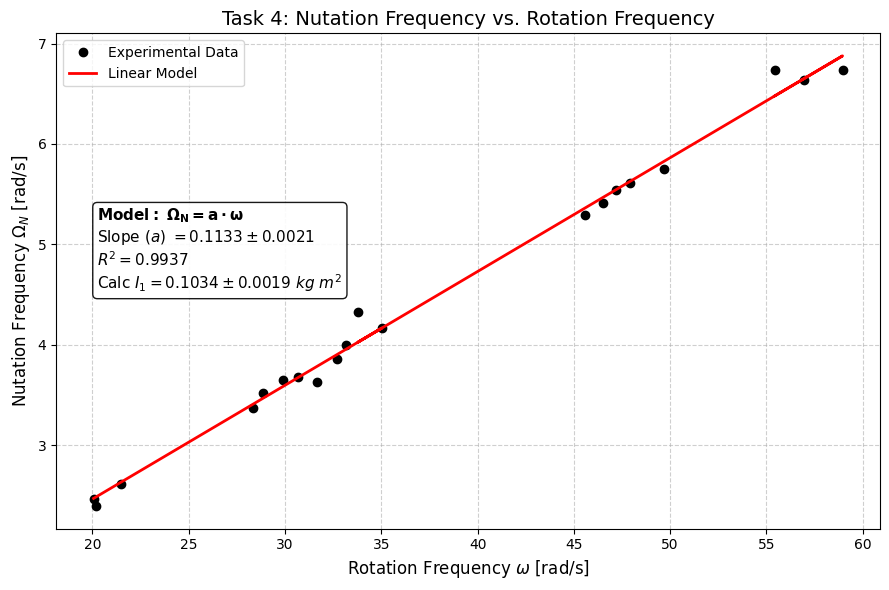

In [ ]:
# --- 6. Plotting ---


plt.figure(figsize=(9, 6))

# DISPLAY DATA (Markers only)
plt.plot(data['omega'], data['omega_n'], 'ko', markersize=6, label='Experimental Data')

# DISPLAY FIT (Continuous line)
plt.plot(data['omega'], intercept + slope * data['omega'], 'r-', linewidth=2, label='Linear Model')

# LABELS WITH UNITS
plt.xlabel(r'Rotation Frequency $\omega$ [rad/s]', fontsize=12)
plt.ylabel(r'Nutation Frequency $\Omega_N$ [rad/s]', fontsize=12)
plt.title('Task 4: Nutation Frequency vs. Rotation Frequency', fontsize=14)

# LEGEND
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

# FITTING RESULTS BOX
textstr = '\n'.join((
    r'$\bf{Model:\ \Omega_N = a \cdot \omega}$',
    r'Slope ($a$) $= %.4f \pm %.4f$' % (slope, std_err),
    r'$R^2 = %.4f$' % (r_squared, ),
    r'Calc $I_1 = %.4f \pm %.4f\ kg\ m^2$' % (I1_calc, I1_err)))

props = dict(boxstyle='round', facecolor='white', alpha=0.9)
plt.gca().text(0.05, 0.65, textstr, transform=plt.gca().transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

.

## 3. Results and Discussion

### 3.1 Analysis of the Linear Relationship
We plotted the nutation frequency $\Omega_N$ as a function of the rotation frequency $\omega$.
* **Linearity:** The regression analysis yields an exceptionally high coefficient of determination (**$R^2 = 0.9937$**). This strongly validates the theoretical prediction that the nutation frequency is directly proportional to the spin rate ($\Omega_N \propto \omega$).
* **Slope:** The slope of the line was determined to be **$0.1133 \pm 0.0021$**. According to theory, this slope corresponds to the ratio of the moments of inertia ($I_3 / I_1$).

### 3.2 Calculation of $I_1$
Using the theoretical moment of inertia for the disk ($I_3 = 0.01172 \text{ kg m}^2$) and our measured slope, we calculated the transverse moment of inertia $I_1$:
$$I_1 = \frac{I_3}{\text{Slope}} = \frac{0.01172}{0.1133}$$
$$\boxed{I_1 \approx 0.1034 \pm 0.0020 \text{ kg m}^2}$$

### 3.3 Physical Interpretation
* **Ratio of Inertias:** The ratio $I_1 / I_3 \approx 8.82$ indicates that the transverse moment of inertia is nearly 9 times larger than the axial moment of inertia.
* **Prolate vs. Oblate:** Since $I_1 > I_3$, the gyroscope system behaves as a **prolate** top (like a pencil spinning on its tip). This might seem counter-intuitive because the disk itself is "oblate" (flat), but $I_1$ represents the inertia of the **entire assembly** (disk + long axle + counterweights) rotating around the pivot point. The counterweights and the disk are positioned far from the center of rotation, contributing significantly to $I_1$ (since $I \propto mr^2$), whereas $I_3$ involves only the mass of the disk close to its own axis.